In [1]:
import pandas as pd

df = pd.read_csv("/Users/dishasanthosh/Library/CloudStorage/OneDrive-Personal/Uni/Projects/retail-ds-project/data/clean_transactions.csv")
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [2]:
monthly_sales = (
    df.set_index('InvoiceDate')
      .resample('M')['TotalPrice']
      .sum()
      .reset_index()
)

monthly_sales.head()

/var/folders/wd/cv2f7dtd0y3ghh2y0s0bdt0r0000gn/T/ipykernel_3051/300731565.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('M')['TotalPrice']


,InvoiceDate,TotalPrice
0,2010-12-31,572713.890
1,2011-01-31,569445.040
2,2011-02-28,447137.350
3,2011-03-31,595500.760
4,2011-04-30,469200.361


In [3]:
monthly_sales.shape

(13, 2)

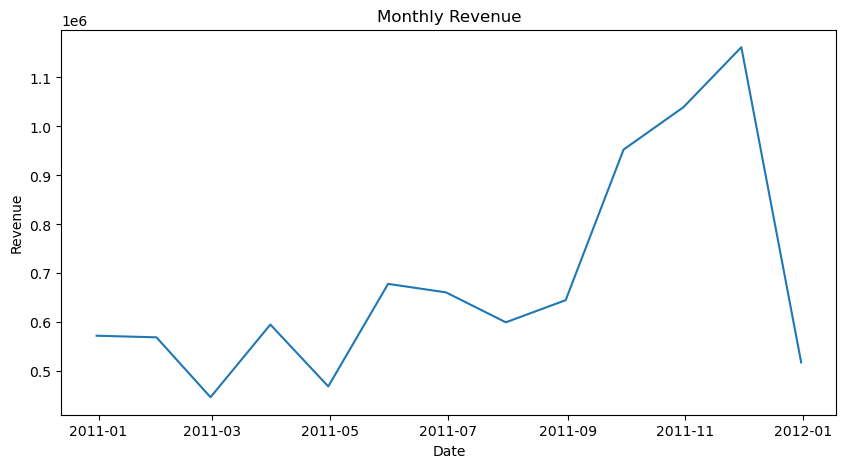

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(monthly_sales['InvoiceDate'],
         monthly_sales['TotalPrice'])
plt.title("Monthly Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()

In [5]:
monthly_sales['lag_1'] = monthly_sales['TotalPrice'].shift(1)
monthly_sales['lag_2'] = monthly_sales['TotalPrice'].shift(2)
monthly_sales['lag_3'] = monthly_sales['TotalPrice'].shift(3)

monthly_sales = monthly_sales.dropna()

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X = monthly_sales[['lag_1', 'lag_2', 'lag_3']]
y = monthly_sales['TotalPrice']

X_train, X_test = X[:-2], X[-2:]
y_train, y_test = y[:-2], y[-2:]

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)

In [7]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, pred)
print("MAE:", mae)

MAE: 316335.0736899999


In [8]:
monthly_sales['TotalPrice'].mean()

np.float64(732211.1624)

In [9]:
mape = (abs(y_test - pred) / y_test).mean()
print("MAPE:", mape)

MAPE: 0.4878947398171389


In [10]:
monthly_sales['rolling_mean_3'] = (
    monthly_sales['TotalPrice']
    .rolling(window=3)
    .mean()
)

monthly_sales['rolling_std_3'] = (
    monthly_sales['TotalPrice']
    .rolling(window=3)
    .std()
)


monthly_sales['Month'] = monthly_sales['InvoiceDate'].dt.month

In [11]:
X = monthly_sales[
    ['lag_1','lag_2','lag_3',
     'rolling_mean_3','rolling_std_3','Month']
]
y = monthly_sales['TotalPrice']

X_train, X_test = X[:-2], X[-2:]
y_train, y_test = y[:-2], y[-2:]

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)

In [12]:
mae = mean_absolute_error(y_test, pred)
print("MAE:", mae)

MAE: 370062.32161500014
